In [1]:
%load_ext autoreload
%autoreload 2

from quantem.core import config

config.set_device(0)
print(config.get("device"))

import pickle

import numpy as np
import torch
from matplotlib import pyplot as plt

from stem_utils import generate_datacube

ACC_VOLTAGE     = 60e3   # eV
PROBE_SEMIANGLE = 20     # mrad
PROBE_DEFOCUS   = 30     # Å
SCAN_STEP_SIZE  = 0.15   # Å
DP_TRIM         = 30     # pixels trimmed off each side of the detector

with open('DIP_phases_wide_stich.pkl', 'rb') as f:
    data = pickle.load(f)

x = data['x']
y = data['y']

cuda:0


In [2]:
def simulate_clean_datacube(phase_image, x=x, y=y):
    """Noise-free 4D-STEM simulation of a single phase image on the shared scan grid."""
    return generate_datacube(
        phase_image, x, y,
        acc_voltage=ACC_VOLTAGE,
        probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS,
        scan_step_size=SCAN_STEP_SIZE,
    )


def checkerboard_mask(shape):
    ii, jj = np.indices(shape)
    return ((ii + jj) % 2 == 0).astype(np.uint8)


def merge_scan(meas_a, meas_b, scan_mask, dose=None, dp_trim=DP_TRIM, normalize=True):
    """Interlace two noise-free measurements on a checkerboard scan pattern.

    `dose` (electrons / Å^2) applies Poisson shot noise to each measurement
    before interlacing; `None` keeps the simulation noise-free.
    """
    m_a = meas_a if dose is None else meas_a.poisson_noise(dose)
    m_b = meas_b if dose is None else meas_b.poisson_noise(dose)

    dcube_a = np.array(m_a.array)[:, :, dp_trim:-dp_trim, dp_trim:-dp_trim]
    dcube_b = np.array(m_b.array)[:, :, dp_trim:-dp_trim, dp_trim:-dp_trim]

    merged_scan = np.where(scan_mask[..., np.newaxis, np.newaxis] == 1, dcube_b, dcube_a)

    if normalize:
        merged_scan = merged_scan / merged_scan.sum(axis=(2, 3), keepdims=True)

    return merged_scan

In [3]:
# Simulate each phase image once (the expensive abtem multislice sim). Image 0 is
# the shared baseline for all three "excited" (defect) images 1-3, so this only
# needs 4 simulations total rather than one pair per comparison.
baseline_meas = simulate_clean_datacube(data['stitched'][0])
excited_meas = {i: simulate_clean_datacube(data['stitched'][i]) for i in (1, 2, 3)}

scan_mask = checkerboard_mask(baseline_meas.array.shape[:2])

tasks:   1%|1         | 2/178 [00:01<01:44,  1.69it/s]

tasks:   1%|1         | 2/178 [00:00<00:46,  3.80it/s]

tasks:   1%|1         | 2/178 [00:00<00:51,  3.44it/s]

tasks:   2%|1         | 3/178 [00:00<00:43,  4.03it/s]

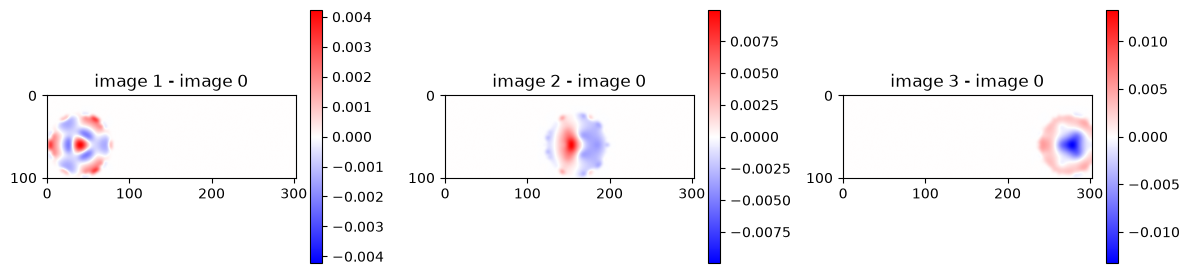

In [4]:
# Ground-truth phase difference for each "excited" image relative to the baseline,
# for reference only (this is what the sliding-window map below is trying to find
# without a full reconstruction).
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, i in zip(axes, (1, 2, 3)):
    diff_img = data['stitched'][i] - data['stitched'][0]
    extent = np.max(np.abs(diff_img))
    im = ax.imshow(diff_img, cmap='bwr', vmin=-extent, vmax=extent)
    ax.set_title(f'image {i} - image 0')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

In [5]:
def _gaussian_kernel2d(sigma, device, dtype, truncate=4.0):
    radius = int(truncate * sigma + 0.5)
    coords = torch.arange(-radius, radius + 1, device=device, dtype=dtype)
    g1d = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g1d = g1d / g1d.sum()
    return g1d[:, None] * g1d[None, :], radius


def compute_nyquist_defect_map(merged_scan, scan_mask, window_size=8, smooth_sigma=None, device=None):
    """Localize phase-change defects in a checkerboard-interlaced 4D-STEM scan.

    Modulating the interlaced scan by +/-1 to match the checkerboard cancels the
    two interlaced conditions wherever they're identical; wherever they differ
    (e.g. a local phase defect) the modulated diffraction patterns sum coherently
    within a sliding window, producing a detectable peak — without needing a full
    ptychographic reconstruction. `smooth_sigma`, if set, Gaussian-blurs each
    window's summed diffraction pattern before taking its peak, to average down
    shot noise.

    Runs on `device` (defaults to `config.get("device")`, e.g. "cuda:0") using a
    summed-area table (2D prefix sum), so every window's sum is computed in one
    vectorized pass instead of looping over each scan position on the CPU.
    """
    if device is None:
        device = config.get("device")

    interlacing_mask = np.where(scan_mask == 0, -1, 1).astype(np.float32)
    scan_modulated = merged_scan.astype(np.float32) * interlacing_mask[..., np.newaxis, np.newaxis]
    t = torch.from_numpy(scan_modulated).to(device)

    ny, nx = t.shape[:2]
    w = window_size
    csum = t.cumsum(dim=0).cumsum(dim=1)
    csum = torch.nn.functional.pad(csum, (0, 0, 0, 0, 1, 0, 1, 0))
    window_sum = (
        csum[w:, w:] - csum[:-w, w:] - csum[w:, :-w] + csum[:-w, :-w]
    )[: ny - w, : nx - w]

    if smooth_sigma is not None:
        wy, wx, dy, dx = window_sum.shape
        kernel, radius = _gaussian_kernel2d(smooth_sigma, device, window_sum.dtype)
        batch = window_sum.reshape(wy * wx, 1, dy, dx)
        batch = torch.nn.functional.pad(batch, (radius, radius, radius, radius), mode="reflect")
        batch = torch.nn.functional.conv2d(batch, kernel[None, None])
        window_sum = batch.reshape(wy, wx, dy, dx)

    half = w // 2
    defect_map = torch.zeros((ny, nx), device=device, dtype=t.dtype)
    defect_map[half:ny - half, half:nx - half] = window_sum.abs().amax(dim=(2, 3))

    return defect_map.cpu().numpy()

In [6]:
# Sweep: 3 excited images x multiple doses. `None` = noise-free; other values are
# electron dose per unit scan area (e/Å^2), spanning a typical 4D-STEM dose range
# (~25-2500 counts/pattern at this scan step).
doses = [None, 1e6] # , 1e5, 1e4]
image_indices = (1, 2, 3)

defect_maps = {}
for image_idx in image_indices:
    for dose in doses:
        merged = merge_scan(baseline_meas, excited_meas[image_idx], scan_mask, dose=dose)
        defect_maps[(image_idx, dose)] = compute_nyquist_defect_map(merged, scan_mask, window_size=16)

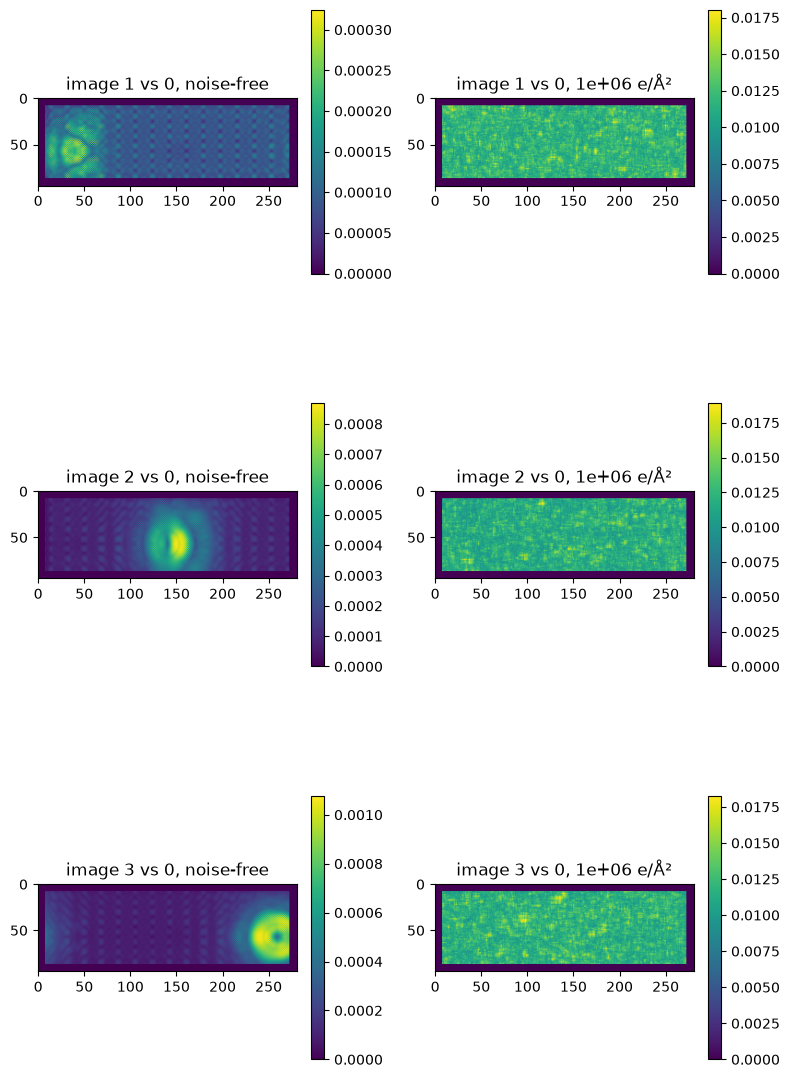

In [7]:
fig, axes = plt.subplots(
    len(image_indices), len(doses),
    figsize=(4 * len(doses), 4 * len(image_indices)),
    squeeze=False,
)
for row, image_idx in enumerate(image_indices):
    for col, dose in enumerate(doses):
        ax = axes[row][col]
        dmap = defect_maps[(image_idx, dose)]
        im = ax.imshow(dmap)
        dose_label = 'noise-free' if dose is None else f'{dose:.0e} e/Å²'
        ax.set_title(f'image {image_idx} vs 0, {dose_label}')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

In [8]:
merged_opt = merge_scan(baseline_meas, excited_meas[3], scan_mask, dose=None)
merged_dose = merge_scan(baseline_meas, excited_meas[3], scan_mask, dose=1e7)

In [9]:
modulation_mask = scan_mask.copy().astype(np.int8)
modulation_mask[modulation_mask == 0] = -1

modulated_scan = merged_dose * modulation_mask[..., np.newaxis, np.newaxis]
modulated_scan_opt = merged_opt * modulation_mask[..., np.newaxis, np.newaxis]


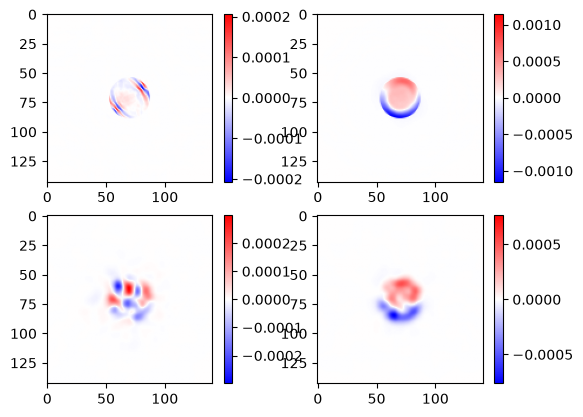

In [10]:
from scipy.ndimage import gaussian_filter
plt.subplot(2,2,1)
nq_pw_clean_opt = modulated_scan_opt[10:30, 10:30, ...].sum(axis=(0,1))
# nq_pw_clean_opt = gaussian_filter(nq_pw_clean_opt, sigma=3)
nq_pw_clean_opt_extent = np.max(np.abs(nq_pw_clean_opt))
plt.imshow(nq_pw_clean_opt, cmap='bwr', vmin=-nq_pw_clean_opt_extent, vmax=nq_pw_clean_opt_extent)
plt.colorbar()

plt.subplot(2,2,2)
nq_pw_defect_opt = modulated_scan_opt[40:60, 250:270, ...].sum(axis=(0,1))
# nq_pw_defect_opt = gaussian_filter(nq_pw_defect_opt, sigma=3)
nq_pw_defect_opt_extent = np.max(np.abs(nq_pw_defect_opt))
plt.imshow(nq_pw_defect_opt, cmap='bwr', vmin=-nq_pw_defect_opt_extent, vmax=nq_pw_defect_opt_extent)
plt.colorbar()


plt.subplot(2,2,3)
nq_pw_clean = modulated_scan[10:30, 10:30, ...].sum(axis=(0,1))
nq_pw_clean = gaussian_filter(nq_pw_clean, sigma=3)
nq_pw_clean_extent = np.max(np.abs(nq_pw_clean))
plt.imshow(nq_pw_clean, cmap='bwr', vmin=-nq_pw_clean_extent, vmax=nq_pw_clean_extent)
plt.colorbar()

plt.subplot(2,2,4)
nq_pw_defect = modulated_scan[40:60, 250:270, ...].sum(axis=(0,1))
nq_pw_defect = gaussian_filter(nq_pw_defect, sigma=3)
nq_pw_defect_extent = np.max(np.abs(nq_pw_defect))
plt.imshow(nq_pw_defect, cmap='bwr', vmin=-nq_pw_defect_extent, vmax=nq_pw_defect_extent)
plt.colorbar()


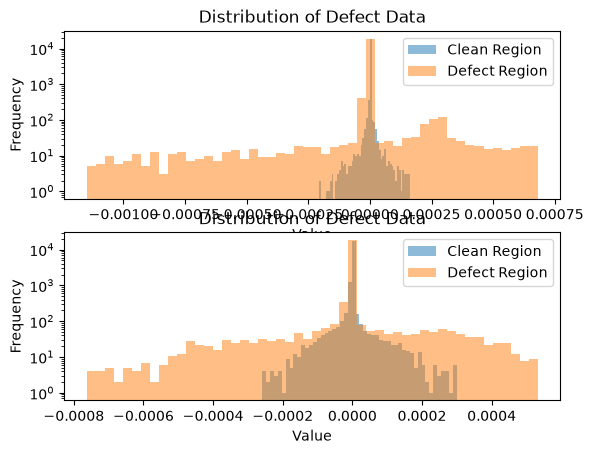

In [11]:
plt.subplot(2,1,1)
plt.hist(nq_pw_clean_opt.flatten(), label='Clean Region', alpha=0.5, bins=50)
plt.hist(nq_pw_defect_opt.flatten(), label='Defect Region', alpha=0.5, bins=50)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Defect Data')
plt.legend()
plt.yscale('log')

plt.subplot(2,1,2)
plt.hist(nq_pw_clean.flatten(), label='Clean Region', alpha=0.5, bins=50)
plt.hist(nq_pw_defect.flatten(), label='Defect Region', alpha=0.5, bins=50)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Defect Data')
plt.legend()
plt.yscale('log')

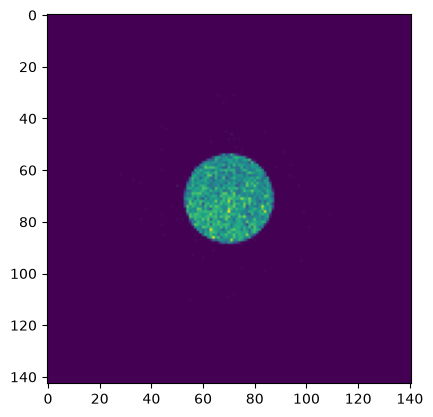

In [12]:
plt.imshow(merged[50, 250])

In [13]:
for image_idx in image_indices:
    for dose in doses:
        dose_label = 'noise-free' if dose is None else f'{dose:.0e}'
        peak = defect_maps[(image_idx, dose)].max()
        print(f'image {image_idx} vs 0, dose={dose_label:>10}: peak defect signal = {peak:.4g}')

image 1 vs 0, dose=noise-free: peak defect signal = 0.0003243
image 1 vs 0, dose=     1e+06: peak defect signal = 0.01802
image 2 vs 0, dose=noise-free: peak defect signal = 0.0008697
image 2 vs 0, dose=     1e+06: peak defect signal = 0.01892
image 3 vs 0, dose=noise-free: peak defect signal = 0.001078
image 3 vs 0, dose=     1e+06: peak defect signal = 0.01827
